## IMPORTS

In [9]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

os.makedirs('../figures', exist_ok=True)
sc.set_figure_params(dpi=100, frameon=False, vector_friendly=True)
sc.settings.figdir = '../figures/'

### Reading data

In [10]:
adata = sc.read_h5ad('../data/adata_qc.h5ad')
adata.layers['counts'] = adata.X.copy()
print(adata)
print("var index name:", adata.var.index.name)
print("var columns:", adata.var.columns.tolist()[:5])

AnnData object with n_obs × n_vars = 98976 × 19027
    obs: 'donor_id', 'sex_ontology_term_id', 'cell_type_ontology_term_id', 'luad_histologic_subtype', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'author_cell_type_level_1', 'author_cell_type_level_2', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'cell_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'is_doublet'
    var: 'gene_symbol', 'feature_is_filtered', 'feature_name', 'feature_reference

## Hierarchical clustering

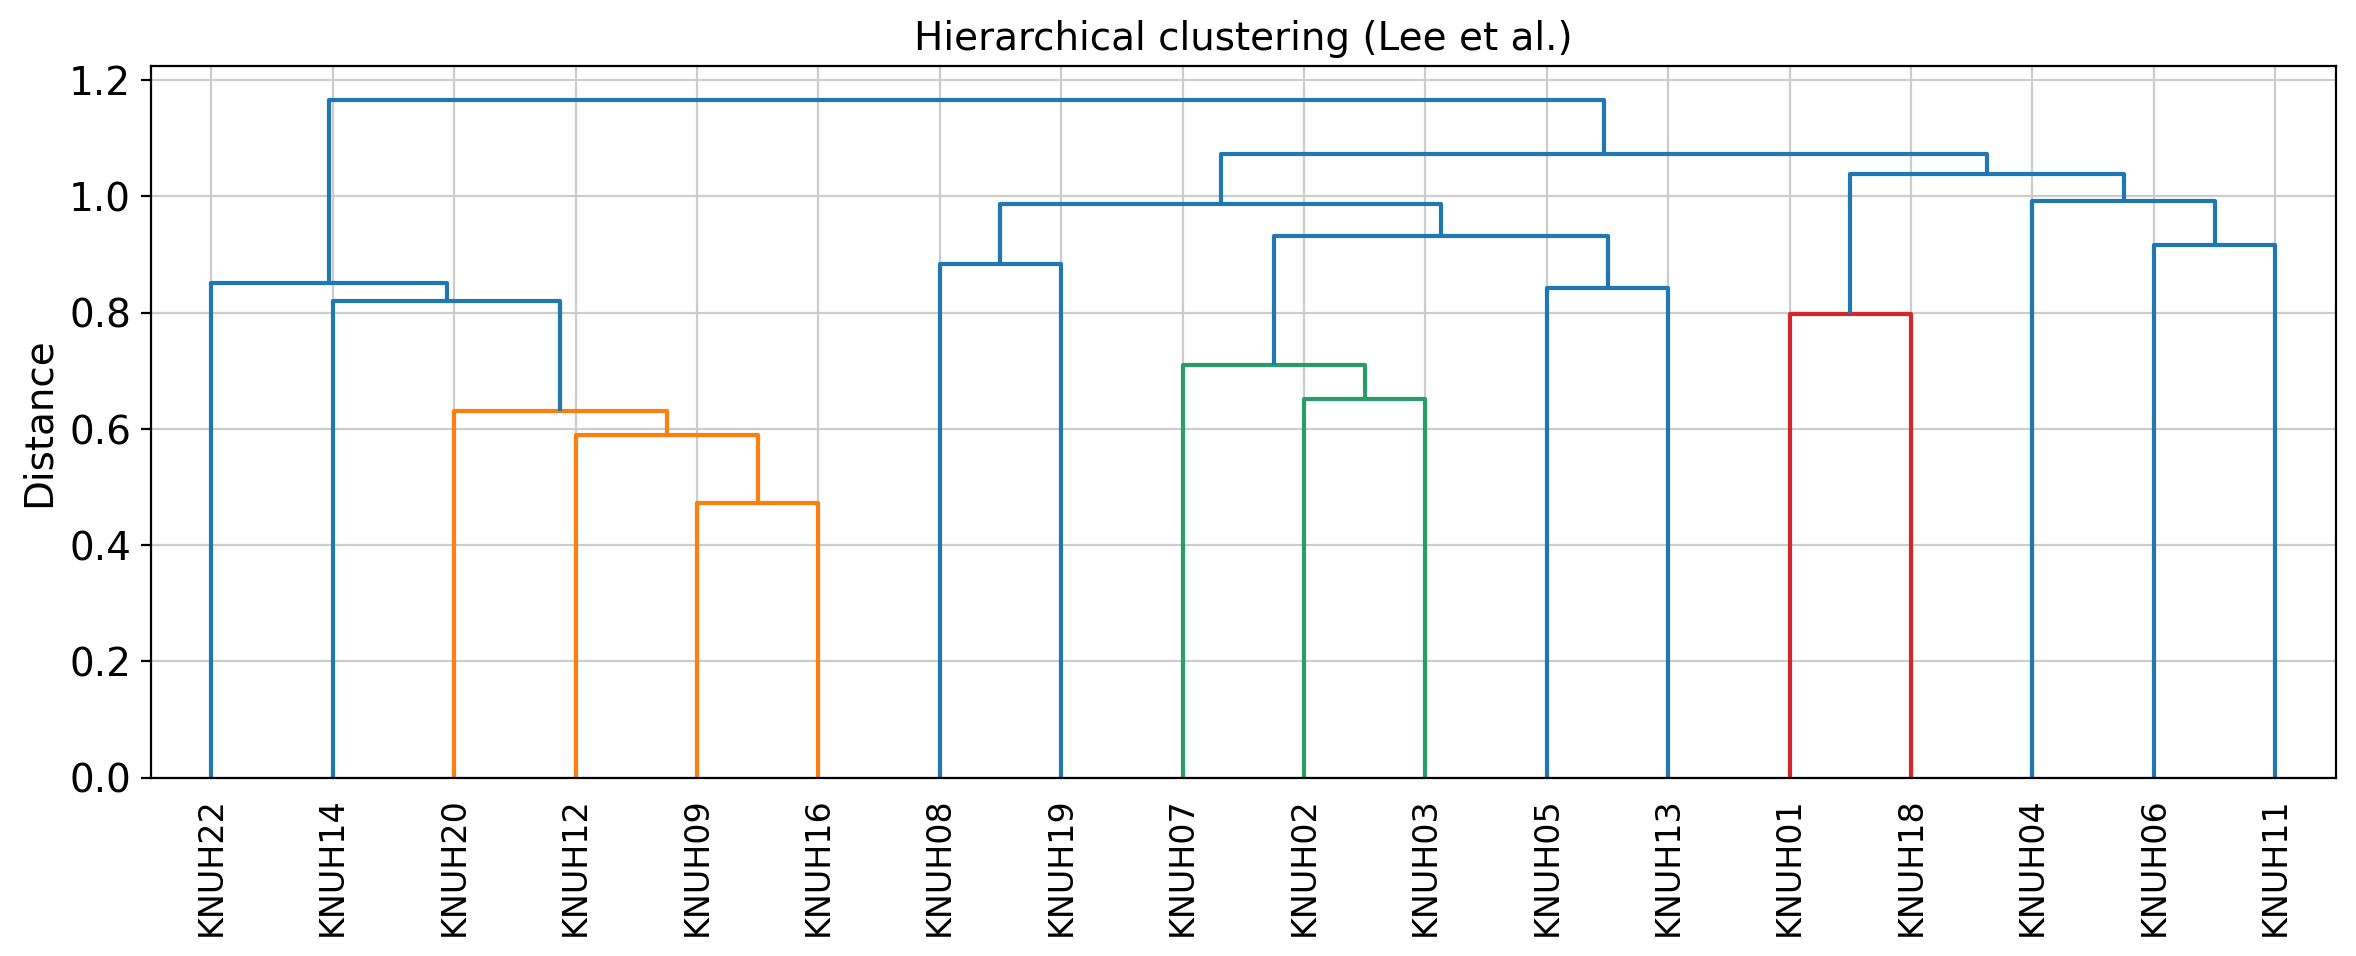

   donor_id  cluster
12   KNUH14        1
13   KNUH16        1
10   KNUH12        1
8    KNUH09        1
17   KNUH22        1
16   KNUH20        1
1    KNUH02        2
2    KNUH03        2
15   KNUH19        2
11   KNUH13        2
7    KNUH08        2
4    KNUH05        2
6    KNUH07        2
3    KNUH04        3
5    KNUH06        3
0    KNUH01        3
14   KNUH18        3
9    KNUH11        3


In [11]:
# pick tumor cells
tumor = adata[adata.obs['cell_group'] == 'Tumor'].copy()

# pseudobulk
donors = tumor.obs['donor_id'].unique()

pb = pd.DataFrame(index=donors, columns=tumor.var_names, dtype=np.float32)

for donor in donors:
    mask = tumor.obs['donor_id'] == donor
    X = tumor[mask].layers['counts']
    if hasattr(X, 'toarray'):
        X = X.toarray()
    pb.loc[donor] = X.sum(axis=0)

# CPM + log2
pb = pb.div(pb.sum(axis=1), axis=0) * 1e6
pb = np.log2(pb + 1)

# HVG among pseudobulk
gene_var = pb.var(axis=0)
top_var_genes = gene_var.nlargest(2000).index
pb_hvg = pb[top_var_genes]

# z-score genes
pb_z = (pb_hvg - pb_hvg.mean(axis=0)) / (pb_hvg.std(axis=0) + 1e-6)

dist = pdist(pb_z.values, metric='correlation')
Z = linkage(dist, method='average')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=donors.tolist(), ax=ax, leaf_rotation=90)
ax.set_title('Hierarchical clustering (Lee et al.)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../figures/hclust_donors.png', dpi=150)
plt.show()

cluster_labels = fcluster(Z, t=3, criterion='maxclust')
cluster_df = pd.DataFrame({
    'donor_id': donors,
    'cluster': cluster_labels
})
print(cluster_df.sort_values('cluster'))

In [ ]:
cluster_df.to_csv('./data/hclust_donors_results.csv')

pb.to_csv('./data/pseudobulk_donors_lee.csv') # pb matrix
np.save('./data/hclust_linkage_Z.npy', Z) # linkage matrix

print('Saved:')
print('  hclust_donors_results.csv')
print('  hclust_donors.png')
print('  pseudobulk_donors_lee.csv')
print('  hclust_linkage_Z.npy')

Saved:
  hclust_donors_results.csv
  hclust_donors.png
  pseudobulk_donors_lee.csv
  hclust_linkage_Z.npy


## Leiden clusterization

In [13]:
tumor = adata[adata.obs['cell_group'] == 'Tumor'].copy()
tumor.X = tumor.layers['counts'].copy() # raw
sc.pp.normalize_total(tumor, target_sum=1e4)
sc.pp.log1p(tumor)

print('После нормализации:')
print('  max:', tumor.X.max())
print('  min:', tumor.X.min())

После нормализации:
  max: 4.8114915
  min: 0.0


/home/bioinf2026/mirny/miniconda3/envs/scanpy_env/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_261082/2657973255.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(tumor_hvg, resolution=0.5)


Clusters: 26
leiden
0     2556
1     2121
2     1833
3     1816
4     1732
5     1518
6     1455
7     1175
8      931
9      861
10     851
11     749
12     718
13     693
14     624
15     538
16     444
17     398
18     261
19     253
20     250
21     119
22      99
23      84
24      54
25      30
Name: count, dtype: int64


/tmp/ipykernel_261082/2657973255.py:17: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tumor_hvg, color='leiden', save='_tumor_clusters.png', legend_loc='on data')


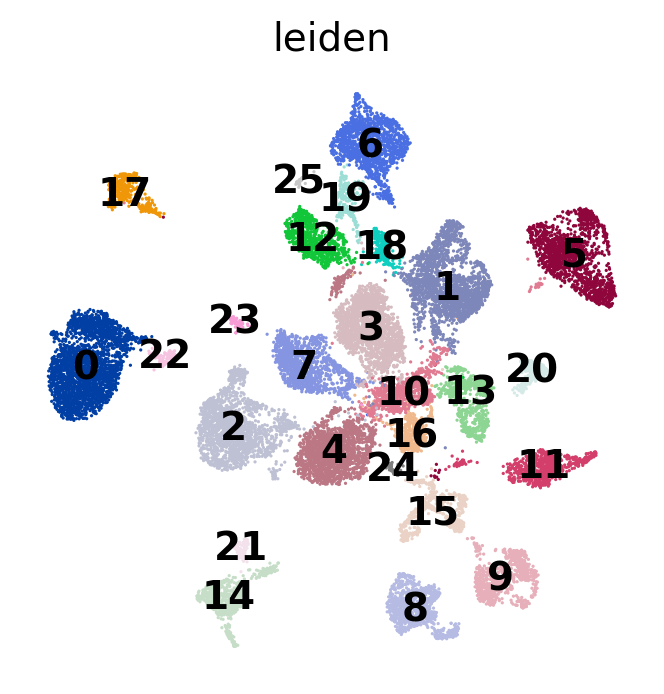

/tmp/ipykernel_261082/2657973255.py:18: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tumor_hvg, color='donor_id', save='_tumor_donors.png')


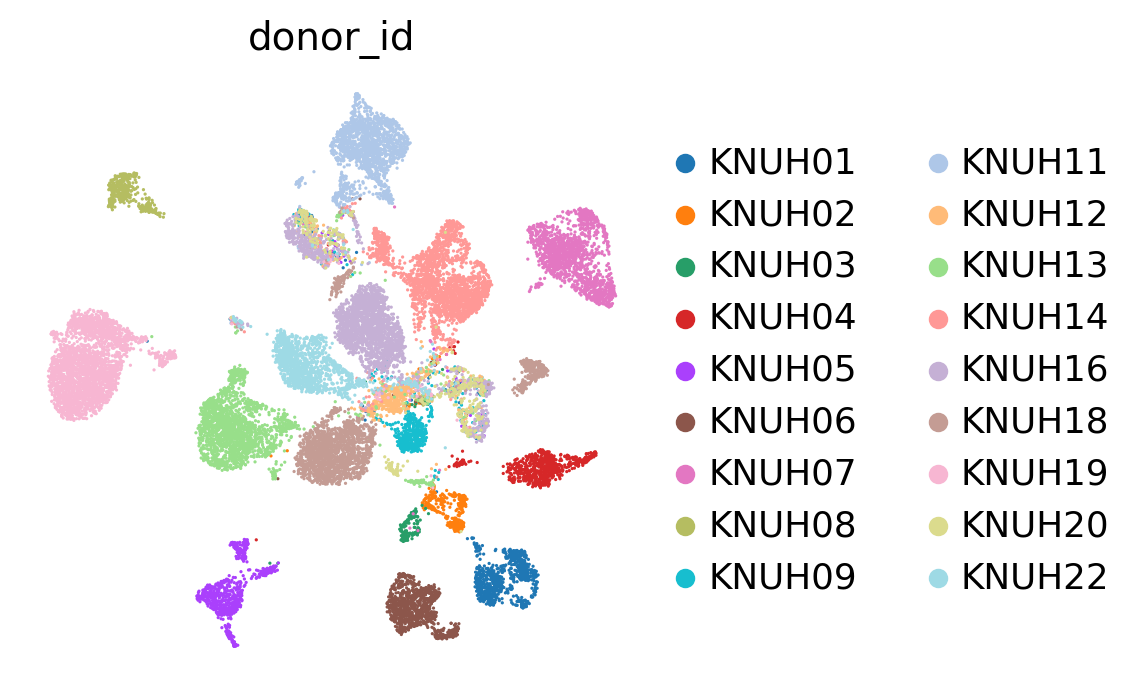

In [14]:
# HVG
sc.pp.highly_variable_genes(tumor, n_top_genes=3000, flavor='seurat')
tumor_hvg = tumor[:, tumor.var.highly_variable].copy()

# scale
sc.pp.scale(tumor_hvg, max_value=10)

# PCA → neighbors → UMAP → leiden
sc.tl.pca(tumor_hvg, n_comps=50)
sc.pp.neighbors(tumor_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(tumor_hvg)
sc.tl.leiden(tumor_hvg, resolution=0.5)

print('Clusters:', tumor_hvg.obs['leiden'].nunique())
print(tumor_hvg.obs['leiden'].value_counts())

sc.pl.umap(tumor_hvg, color='leiden', save='_tumor_clusters.png', legend_loc='on data')
sc.pl.umap(tumor_hvg, color='donor_id', save='_tumor_donors.png')

2026-05-21 21:43:29,306 - harmonypy - INFO - Running Harmony
2026-05-21 21:43:29,306 - harmonypy - INFO -   Parameters:
2026-05-21 21:43:29,307 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-21 21:43:29,307 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-21 21:43:29,308 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-21 21:43:29,308 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-21 21:43:29,308 - harmonypy - INFO -     nclust: 100
2026-05-21 21:43:29,309 - harmonypy - INFO -     block_size: 0.05
2026-05-21 21:43:29,309 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-21 21:43:29,310 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-21 21:43:29,311 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-21 21:43:29,311 - harmonypy - INFO -     verbose: True
2026-05-21 21:43:29,311 - harmonypy - INFO -     random_state: 0
2026-05-21 21:43:29,312 - harmonypy - INFO -   Data: 50 PCs × 22163 cells
20

2026-05-21 21:43:29,330 - harmonypy - INFO - Computing initial centroids...
2026-05-21 21:43:30,333 - harmonypy - INFO - Initialization complete.


X_pca shape: (22163, 50)
Должно быть (37048, 50)


2026-05-21 21:43:30,334 - harmonypy - INFO - Iteration 1 of 10
2026-05-21 21:43:30,944 - harmonypy - INFO - Iteration 2 of 10
2026-05-21 21:43:31,613 - harmonypy - INFO - Iteration 3 of 10
2026-05-21 21:43:32,293 - harmonypy - INFO - Iteration 4 of 10
2026-05-21 21:43:32,978 - harmonypy - INFO - Iteration 5 of 10
2026-05-21 21:43:33,665 - harmonypy - INFO - Converged after 5 iterations


X_harmony shape: (22163, 50)


/tmp/ipykernel_261082/919914380.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(tumor_hvg, resolution=0.5)


Clusters: 14


/tmp/ipykernel_261082/919914380.py:18: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tumor_hvg, color='leiden', save='_harmony_clusters.png', legend_loc='on data')


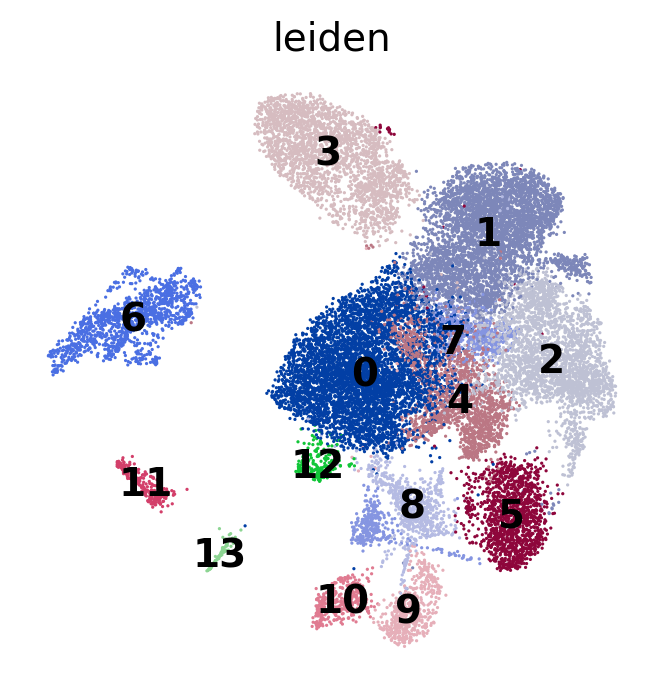

/tmp/ipykernel_261082/919914380.py:19: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(tumor_hvg, color='donor_id', save='_harmony_donors.png')


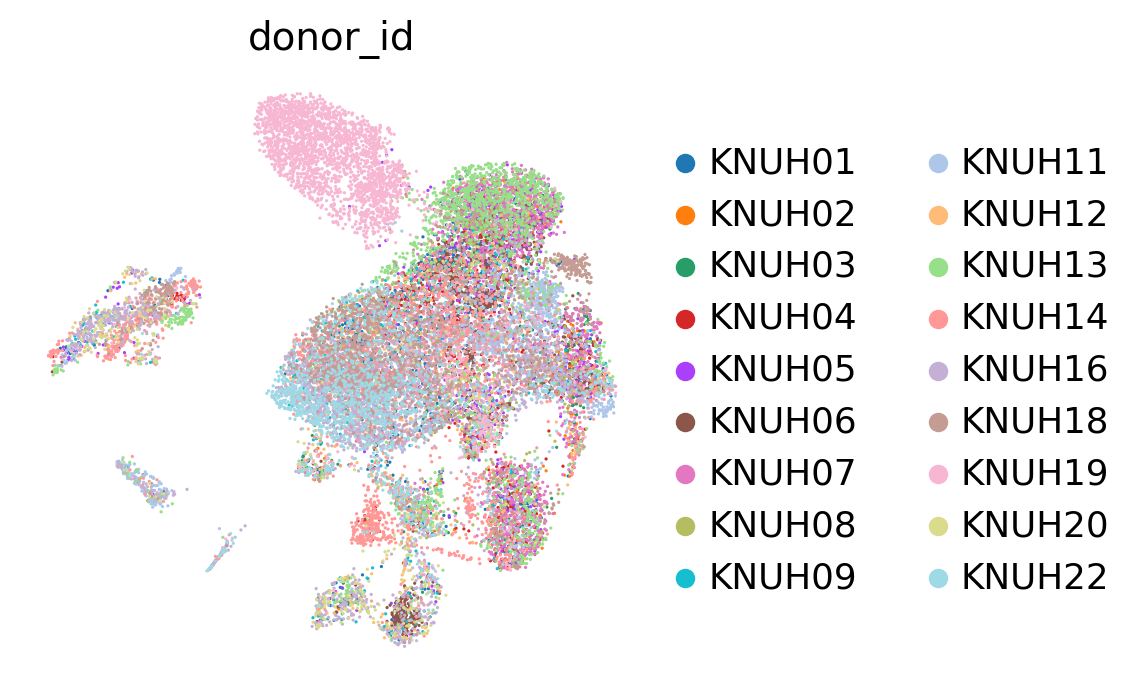

In [15]:
X_pca = tumor_hvg.obsm['X_pca'].astype(np.float64)
print('X_pca shape:', X_pca.shape)
print('Должно быть (37048, 50)')

ho = hm.run_harmony(X_pca, tumor_hvg.obs, 'donor_id')

X_harmony = ho.Z_corr
print('X_harmony shape:', X_harmony.shape)

tumor_hvg.obsm['X_pca_harmony'] = X_harmony

# дальше как обычно
sc.pp.neighbors(tumor_hvg, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(tumor_hvg)
sc.tl.leiden(tumor_hvg, resolution=0.5)

print('Clusters:', tumor_hvg.obs['leiden'].nunique())
sc.pl.umap(tumor_hvg, color='leiden', save='_harmony_clusters.png', legend_loc='on data')
sc.pl.umap(tumor_hvg, color='donor_id', save='_harmony_donors.png')

In [16]:
ct = pd.crosstab(tumor_hvg.obs['leiden'], tumor_hvg.obs['donor_id'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
for cluster in sorted(ct.index, key=int):
    top_donor = ct_norm.loc[cluster].idxmax()
    top_frac = ct_norm.loc[cluster].max()
    n_cells = ct.loc[cluster].sum()
    print(f'Cluster {cluster}: {n_cells} cells, dominationg donor: {top_donor} ({top_frac:.0%})')

Cluster 0: 5274 cells, dominationg donor: KNUH16 (24%)
Cluster 1: 4427 cells, dominationg donor: KNUH13 (23%)
Cluster 2: 2691 cells, dominationg donor: KNUH11 (24%)
Cluster 3: 2373 cells, dominationg donor: KNUH19 (99%)
Cluster 4: 1687 cells, dominationg donor: KNUH18 (14%)
Cluster 5: 1375 cells, dominationg donor: KNUH07 (29%)
Cluster 6: 1267 cells, dominationg donor: KNUH14 (27%)
Cluster 7: 927 cells, dominationg donor: KNUH14 (44%)
Cluster 8: 691 cells, dominationg donor: KNUH13 (17%)
Cluster 9: 546 cells, dominationg donor: KNUH06 (32%)
Cluster 10: 356 cells, dominationg donor: KNUH16 (33%)
Cluster 11: 259 cells, dominationg donor: KNUH11 (55%)
Cluster 12: 199 cells, dominationg donor: KNUH22 (17%)
Cluster 13: 91 cells, dominationg donor: KNUH16 (35%)
